# 🚗 05b — Tốc độ & Giá/km trên GIÁ CƠ BẢN (trước khi nhân hệ số)

`05_kmpertime.ipynb` đo ảnh hưởng của quãng đường/thời gian/tắc đường lên **`target_shown_price`**
(giá cuối, ĐÃ NHÂN hệ số surge) — nên phần ảnh hưởng đo được có thể **lẫn cả** phần do surge gây ra
(vd tắc đường giờ cao điểm thường trùng giờ surge cao → khó tách 2 nguyên nhân).

Notebook này tách `base_price = target_shown_price / target_shown_multiplier` (giá **TRƯỚC** khi
nhân hệ số) rồi lặp lại đúng phân tích đó — để xem ảnh hưởng của quãng đường/thời gian/tắc đường
lên **riêng phần giá gốc**, không bị surge làm nhiễu.

> ### ⚠️ Phạm vi của notebook này
>
> Notebook này phân tích trên **giá cơ bản** (`base_price` = giá cuối ÷ hệ số nhân) — mục tiêu là
> tìm cách cải thiện **model giá cơ bản**, nên đã **chủ động loại bỏ phần surge**.
>
> **KHÔNG được diễn giải kết quả ở đây thành "giờ/thời tiết không ảnh hưởng giá".** Giờ/thời tiết
> tác động lên giá khách trả **qua kênh hệ số nhân (surge)**, không qua giá cơ bản. Xem
> **`00_TONG_HOP_SO_SANH.ipynb`** để có bức tranh đầy đủ (tách rõ giá cơ bản / hệ số nhân / giá cuối).

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)
df["base_price"] = df[PRICE] / df[SURGE].clip(lower=0.1)
df["base_price_k"] = df.base_price / 1000
print(f"Gia cuoi   median: {df[PRICE].median():,.0f} VND")
print(f"Gia co ban median: {df.base_price.median():,.0f} VND (= gia cuoi / he so nhan)")
print(f"He so nhan trung binh: {df[SURGE].mean():.3f}")

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%
Gia cuoi   median: 114,000 VND
Gia co ban median: 99,291 VND (= gia cuoi / he so nhan)
He so nhan trung binh: 1.165


**1. Quãng đường/thời gian có ảnh hưởng gì đến GIÁ CƠ BẢN? (kiểm soát quãng đường)**

Lặp lại phân tích ở `04_traffic.ipynb` bước 2, nhưng target đổi từ `target_shown_price` → `base_price`.

corr(quang duong, gia co ban) = 0.764
corr(thoi luong, gia co ban)  = 0.700
corr(thoi luong, gia co ban) TRONG cung dai quang duong (kiem soat) = 0.462
-> So sanh voi ban goc (target_shown_price) o 04_traffic.ipynb de xem phan anh huong
   con lai sau khi da bo surge la bao nhieu.


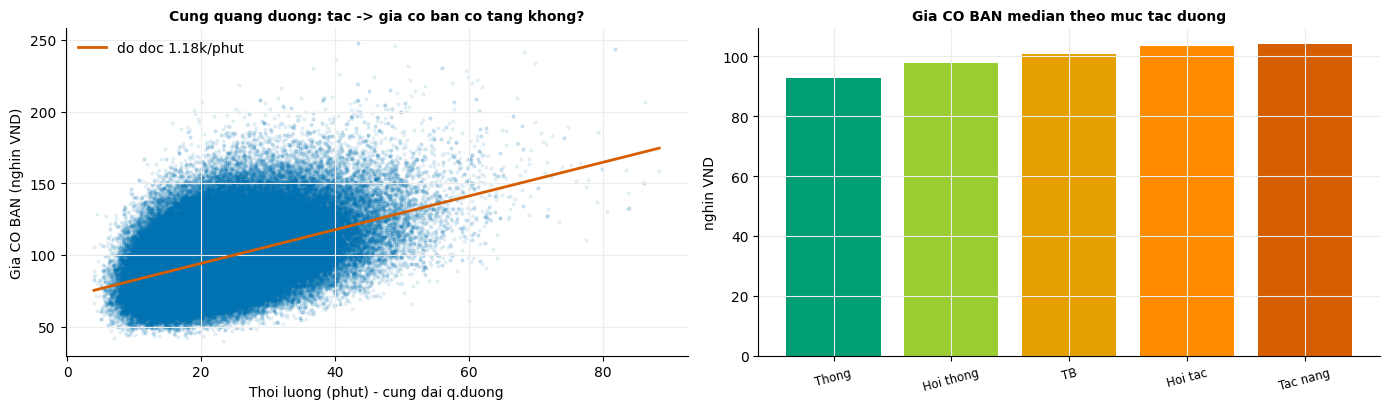

In [2]:
print(f"corr(quang duong, gia co ban) = {df.quote_distance.corr(df.base_price):.3f}")
print(f"corr(thoi luong, gia co ban)  = {df.quote_duration.corr(df.base_price):.3f}")
r_ctrl = control_distance_corr(df, "quote_duration", "base_price")
print(f"corr(thoi luong, gia co ban) TRONG cung dai quang duong (kiem soat) = {r_ctrl:.3f}")
print("-> So sanh voi ban goc (target_shown_price) o 04_traffic.ipynb de xem phan anh huong")
print("   con lai sau khi da bo surge la bao nhieu.")

mid = df.quote_distance.median()
band = df[(df.quote_distance>mid*0.9)&(df.quote_distance<mid*1.1)]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].scatter(band.quote_duration/60, band.base_price_k, s=4, alpha=.08, color=BLUE)
z=np.polyfit(band.quote_duration/60, band.base_price_k,1); xs=np.linspace((band.quote_duration/60).min(),(band.quote_duration/60).max(),50)
ax[0].plot(xs,np.polyval(z,xs),color=RED,lw=2,label=f"do doc {z[0]:.2f}k/phut")
ax[0].set_xlabel("Thoi luong (phut) - cung dai q.duong"); ax[0].set_ylabel("Gia CO BAN (nghin VND)")
ax[0].set_title("Cung quang duong: tac -> gia co ban co tang khong?", fontweight="bold", fontsize=10); ax[0].legend(frameon=False)

df["tacbin"] = pd.qcut(df.dur_per_km, 5, labels=["Thong","Hoi thong","TB","Hoi tac","Tac nang"], duplicates="drop")
g = df.groupby("tacbin").base_price_k.median()
ax[1].bar(range(len(g)), g.values, color=[GREEN,"#9ACD32",ORANGE,"#FF8C00",RED][:len(g)])
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels(g.index, rotation=15, fontsize=8.5)
ax[1].set_title("Gia CO BAN median theo muc tac duong", fontweight="bold", fontsize=10); ax[1].set_ylabel("nghin VND")
plt.tight_layout(); plt.show()

**2. Đơn giá/km trên GIÁ CƠ BẢN — có giảm dần theo quãng đường không?**

Gia co ban/km median: 15,741 VND/km
CV gia co ban       : 0.330
CV gia co ban/km    : 0.281


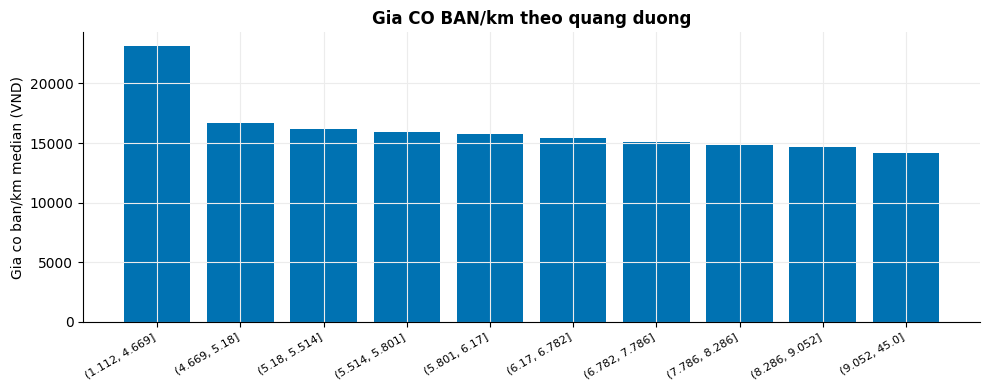

corr(quang duong, gia co ban/km) = -0.496


In [3]:
df["base_price_per_km"] = df.base_price / df.quote_distance.clip(lower=0.1)
print(f"Gia co ban/km median: {df.base_price_per_km.median():,.0f} VND/km")
print(f"CV gia co ban       : {(df.base_price.std()/df.base_price.mean()):.3f}")
print(f"CV gia co ban/km    : {(df.base_price_per_km.std()/df.base_price_per_km.mean()):.3f}")

g = df.groupby(binned(df.quote_distance, 10)).base_price_per_km.median()
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(range(len(g)), g.values, color=BLUE)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, fontsize=8, ha="right")
ax.set_ylabel("Gia co ban/km median (VND)"); ax.set_title("Gia CO BAN/km theo quang duong", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"corr(quang duong, gia co ban/km) = {df.quote_distance.corr(df.base_price_per_km):.3f}")

**3. Đơn giá/km trên GIÁ CƠ BẢN — có tăng khi tắc đường không?**

corr(toc do km/h, gia co ban/km) = -0.413
corr(phut/km, gia co ban/km)     = 0.505


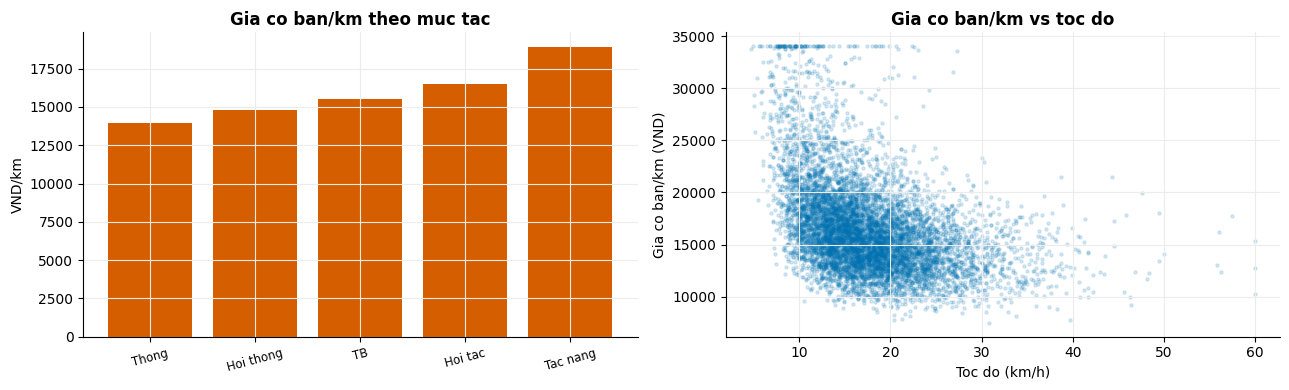

In [4]:
corr_speed = df.speed_kmh.corr(df.base_price_per_km)
corr_durkm = df.dur_per_km.corr(df.base_price_per_km)
print(f"corr(toc do km/h, gia co ban/km) = {corr_speed:.3f}")
print(f"corr(phut/km, gia co ban/km)     = {corr_durkm:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
g1 = df.groupby("tacbin").base_price_per_km.median()
ax[0].bar(range(len(g1)), g1.values, color=RED)
ax[0].set_xticks(range(len(g1))); ax[0].set_xticklabels(g1.index, rotation=15, fontsize=8.5)
ax[0].set_title("Gia co ban/km theo muc tac", fontweight="bold"); ax[0].set_ylabel("VND/km")

s = df.sample(min(8000,len(df)), random_state=0)
ax[1].scatter(s.speed_kmh.clip(0,60), s.base_price_per_km.clip(0, s.base_price_per_km.quantile(.99)), s=5, alpha=.15, color=BLUE)
ax[1].set_xlabel("Toc do (km/h)"); ax[1].set_ylabel("Gia co ban/km (VND)"); ax[1].set_title("Gia co ban/km vs toc do", fontweight="bold")
plt.tight_layout(); plt.show()

**4. Kiểm chứng — dự đoán GIÁ CƠ BẢN/KM rồi × quãng đường có tốt hơn dự đoán GIÁ CƠ BẢN thẳng không?**

Giống bước kiểm chứng ở `05_kmpertime.ipynb` phần Giá/km, nhưng target là `base_price` (không có
surge lẫn vào) — đây là con số thật sự dùng trong model `train_hybrid.ipynb`.

In [5]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

CAT = ["service_name","pickup_location_name","dropoff_location_name"]
NUM = ["quote_distance","quote_duration","gio_vn","latest_observed_price",
       "history_60m_price_mean","history_60m_price_std"]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X = df[NUM].copy()
X[CAT] = enc.fit_transform(df[CAT].astype(str))
X = X[CAT+NUM]

idx_tr, idx_te = train_test_split(df.index, test_size=0.2, random_state=42)
Xtr, Xte = X.loc[idx_tr], X.loc[idx_te]
dist_te = df.loc[idx_te, "quote_distance"].clip(lower=0.1)
base_te = df.loc[idx_te, "base_price"]

def tao():
    return HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, categorical_features=CAT, random_state=42)

mA = tao().fit(Xtr, np.log(df.loc[idx_tr, "base_price"]))
predA = np.exp(mA.predict(Xte))

mC = tao().fit(Xtr, np.log(df.loc[idx_tr, "base_price_per_km"]))
predC_perkm = np.exp(mC.predict(Xte))
predC = predC_perkm * dist_te

print("(A) Du doan thang GIA CO BAN:")
print(f"    R2={r2_score(base_te,predA):.4f}  MAE={mean_absolute_error(base_te,predA):,.0f} VND  MAPE={np.mean(np.abs((base_te-predA)/base_te))*100:.1f}%")
print("(C) Du doan GIA CO BAN/KM roi nhan lai quang duong:")
print(f"    R2={r2_score(base_te,predC):.4f}  MAE={mean_absolute_error(base_te,predC):,.0f} VND  MAPE={np.mean(np.abs((base_te-predC)/base_te))*100:.1f}%")
print(f"\nChenh lech MAE (C - A) = {mean_absolute_error(base_te,predC)-mean_absolute_error(base_te,predA):+,.0f} VND")
print("-> Am (C tot hon): nen doi train_hybrid.ipynb sang doan base_price_per_km.")
print("-> Duong/gan 0: giu nguyen cach doan thang base_price nhu hien tai.")

(A) Du doan thang GIA CO BAN:
    R2=0.6580  MAE=14,987 VND  MAPE=14.5%
(C) Du doan GIA CO BAN/KM roi nhan lai quang duong:
    R2=0.6594  MAE=14,982 VND  MAPE=14.6%

Chenh lech MAE (C - A) = -5 VND
-> Am (C tot hon): nen doi train_hybrid.ipynb sang doan base_price_per_km.
-> Duong/gan 0: giu nguyen cach doan thang base_price nhu hien tai.


**Kết luận**

- So kết quả bước 1-3 với bản gốc (`05_kmpertime.ipynb`, dùng `target_shown_price`) — nếu tương quan
  **giảm đi** sau khi bỏ surge, nghĩa là 1 phần ảnh hưởng "tắc đường làm tăng giá" quan sát được trước
  đó thực ra đến từ surge (tắc đường hay trùng giờ cao điểm/surge cao), không phải giá cơ bản thật sự
  tăng. Nếu tương quan **giữ nguyên/gần bằng**, nghĩa là quãng đường/thời gian ảnh hưởng THẬT SỰ đến
  giá cơ bản (đúng như cấu trúc cước tính theo phút di chuyển).
- Bước 4 cho biết trực tiếp: có nên đổi `train_hybrid.ipynb` sang học `base_price_per_km` thay vì
  `base_price` trực tiếp hay không.